In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

## Opgave 1. (10 point) Antag at 𝐴 er en $4 \times 4$-matrice. Hvad kan siges om dens tilhørende egenværdier?

Når ligning fra proposition 21.15 opstilles vil der kun være n-rækker og dermed n ligninger med n ubekendte. I dette tilfælde vil det være 4. Der vil da maks være 4 egenværdier, dog med chance for at nogle rækker går ud med hinanden, hvilket giver mulighed for færre egenværdier. Svaret er da B.

## Opgave 2. (10 point) Betragt et lineært ligningssystem med $m = 3$ ligninger og $n = 2$ ubekendte. Hvad kan vi sige om antallet af mulige løsninger til systemet?

Hvis 2 af ligningerne er ens eller svarer til hinanden med en faktor ganget på vil de ikke give yderligere information. I dette tilfælde ville det svare til 2 ligninger med 2 ubekendte, hvilket giver præcis en løsning. 3 uafhængige ligninger vil dog give uendeligt mange, hvilket vil sige at vi ikke kan sige noget med informationen. Svaret er dermed D. 

## Opgave 3. (10 point) Hvis en samling af vektorer 𝑢0, 𝑢1, ...,𝑢𝑘−1 er lineært uafhængige, hvad gælder så for ligningen
$$
s_{0} u_{0} + s_{1} + u_{1} + \dots + s_{k-1} u_{k-1} = 0
$$
med $s_{i}$ skalarer?

Ifølge definition 14.2 i notesættet er svaret B.

## Opgave 4. (10 point) Lad 𝐴,𝐵,𝐶 være matricer med 𝐴 ∈ℝ5×1000, 𝐵 ∈ℝ1000×200 og 𝐶 ∈ ℝ1000×200. Hvilke af de følgende matrixberegninger kræver færrest flops, og hvor mange flops bruges der for denne beregning? (i) 𝐴(𝐵 +𝐶)eller (ii) 𝐴𝐵 +𝐴𝐶

In [21]:
# Funktion defineret ud fra matrixprodukt omkostning fra tabel 5.1 i notesættet
def product_flops(M1,M2):
    S1 = M1.shape
    S2 = M2.shape
    return S1[0] * S2[1] * 2 * S2[0]

# Funktion defineret ud fra matrixsum omkostning fra tabel 5.1 i notesættet
def sum_flops(M1, M2):
    S1 = M1.shape
    return S1[0] * S1[1]

In [22]:
A = np.ones((5,1000))
B = np.ones((1000,200))
C = np.ones((1000,200))

# A(B + C)
print("A(B + C):", product_flops(A, B + C) + sum_flops(B, C))

# AB + AC
print("AB + AC:", product_flops(A, B) + sum_flops(A@B, A@C) + product_flops(A, C))

A(B + C): 2200000
AB + AC: 4001000


Det kan ses at (i) A(B + C) kun bruger 2200000 flops, hvilket gør det til den der kræver færrest flops.

## Opgave 5. (20 point) Betragt de følgende vektorer i $\mathbb{R}^{3}$:
$$
v_{0} =
\begin{bmatrix}
3 \\
1 \\
-3
\end{bmatrix}
, \qquad
v_{1} =
\begin{bmatrix}
1 \\
0 \\
1
\end{bmatrix}
, \qquad
v_{2} =
\begin{bmatrix}
-1 \\
6 \\
1
\end{bmatrix}
$$

### (a) Gør rede for at $v_{0}, v_{1}, v_{2}$ er en ortogonal samling.

In [23]:
v0 = np.array([3, 1, -3])[:, np.newaxis]
v1 = np.array([1, 0, 1])[:, np.newaxis]
v2 = np.array([-1, 6, 1])[:, np.newaxis]

V = np.column_stack((v0, v1, v2))
G = V.T @ V
G

array([[19,  0,  0],
       [ 0,  2,  0],
       [ 0,  0, 38]])

Det kan ses at alle værdierne udenfor diagonalen er 0. I en grammatrix svarer det til at vektorsamlingen er ortogonal, da den $(i,j)$'te indgang er det indre produkt mellem $v_{i}$ og $v_{j}$ (jvf. afsnit 9.3 af notesættet).

### (b) Ved at beregne indreprodukter, skriv $w = (1,2,3)$, som lineær kombination $x_{0}v_{0} + x_{1}v_{1} + x_{2}v_{2}$ af $v_{0}, v_{1}, v_{2}$.

In [24]:
# følger Proposition 8.17
w = np.array([1,2,3])[:, np.newaxis]

x0 = np.vdot(w, v0) / (np.linalg.norm(v0)**2)
x1 = np.vdot(w, v1) / (np.linalg.norm(v1)**2)
x2 = np.vdot(w, v2) / (np.linalg.norm(v2)**2)

x0, x1, x2

(-0.21052631578947364, 1.9999999999999996, 0.36842105263157904)

### (c) Brug derefter Parsevals identitet til at beregne $||w||_{2}$.

In [25]:
# parsevals identitet fra proposition 8.17
w2 = np.sqrt(x0**2 * np.linalg.norm(v0)**2 + x1**2 * np.linalg.norm(v1)**2 + x2**2 * np.linalg.norm(v2)**2)
w2

3.7416573867739413

### (d) Dan en ortogonal matrix 𝐴 hvis søjler er proportionelle med $v_{0}, v_{1}, v_{2}$.

Da det vides fra ogpave (a) at vektorerne er ortogonale, skal de blot deles med deres egen længde for at gøre dem til en ortonormal samling. $A$ er da blot denne ortonormale samling/ortogonale matrix.

In [26]:
A = np.column_stack((v0 / np.linalg.norm(v0), v1 / np.linalg.norm(v1), v2 / np.linalg.norm(v2)))
print(A)

[[ 0.6882472   0.70710678 -0.16222142]
 [ 0.22941573  0.          0.97332853]
 [-0.6882472   0.70710678  0.16222142]]


## Opgave 6. (20 point) Betragt de følgende datapunkte

### (a) Forklar hvordan dette svarer til at løse et lineært ligningssystem 𝐴𝑣 =𝑏 og hvorfor man kan ikke forvente en eksakt løsning.

In [27]:
x_data = np.array([0.2, 1.2, 2.7, 3.6, 4.2, 5.9, 6.2])
A = np.vander(x_data, 5)
A.shape

(7, 5)

Det kan ses at der er flere rækker en søjler, hvilket vil sige at man ikke kan forvente en eksakt løsning, som rammer alle datapunkter med kun en fjerdegradspolynomium. 

### (b) Ved brug af en tynd 𝑄𝑅-dekomponering, f.eks. via den forbedrede Gram-Schmidt proces, bestem i python den mindste kvadraters løsning til systemet 𝐴𝑣 =𝑏.

In [28]:
# Fra afsnit 15.3 i notesættet
def forbedret_gram_schmidt(a):
    _, k = a.shape
    q = np.copy(a)
    r = np.zeros((k, k))
    for i in range(k):
        r[i, i] = np.linalg.norm(q[:, i])
        q[:, i] /= r[i, i]
        r[[i], i+1:] = q[:, [i]].T @ q[:, i+1:]
        q[:, i+1:] -= q[:, [i]] @ r[[i], i+1:]
    return q, r

# Fra afsnit 16.4 i notesættet
def back_subs(r, c):
    _, n = r.shape
    x = np.empty((n, 1))
    for i in reversed(range(n)):
        x[i] = (c[i] - r[[i], i+1:] @ x[i+1:]) / r[i, i]
    return x

In [34]:
y_data = np.array([-1.2, 0.1, 1.3, -0.2, -1.9, 0.3, -0.7])

# Laver QR-dekomponering med forbedret gram-schmidt
q, r = forbedret_gram_schmidt(A)
b = y_data

# Løser som i ligning 16.4 fra notesættet
v = back_subs(r, q.T @ b)
print("løsning: \n", v)

løsning: 
 [[ 0.01673881]
 [-0.0627114 ]
 [-0.66474578]
 [ 2.85255245]
 [-1.87401341]]


### (c) Giv en python plot af datapunkterne og polynomiet bestemt af din løsning til del (b).

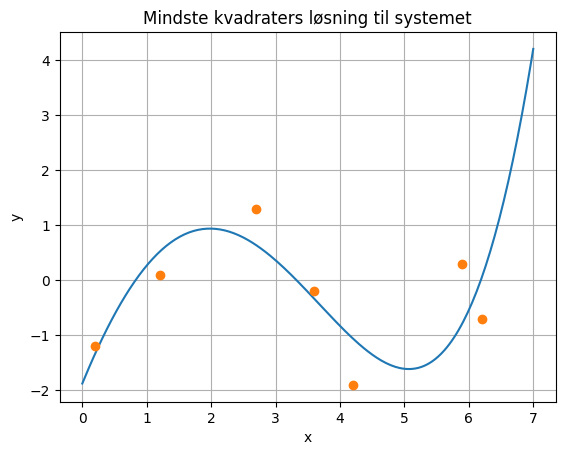

In [37]:
# Plot simpel funktionsudtryk med lables n stuff
x = np.linspace(0, 7, 200)
y = v[0]*x**4 + v[1]*x**3 + v[2]*x**2 + v[3]*x + v[4]

fig, ax = plt.subplots()
ax.plot(x, y) # matplotlib supporter markdown/latex syntaks
ax.plot(x_data, y_data, "o")
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Mindste kvadraters løsning til systemet')
ax.grid()

### (d) Brug python til at bestemme konditionstallet 𝜅(𝐴). Giv desuden en øvre grænse for konditionstallet 𝜅 for beregning, som funktion af 𝐴, af den mindste kvadraters løsning 𝑣 til 𝐴𝑣 =𝑏.

In [66]:
u, s, vt = np.linalg.svd(A)

# ligning 11.10
kA = s[0] / s[-1]

# ligning 17.1 siger at Av = Pb, så vinklen mellem Av og b kan findes således
theta = np.arccos(np.linalg.norm(A @ v, 2) / np.linalg.norm(b, 2))

eta = s[0] * (np.linalg.norm(v, 2) / np.linalg.norm(A @ v, 2))

# ligning 17.2
kappa = kA + (kA**2 * np.abs(np.tan(theta))) / eta

print(f"κ(A) = {kA} \nDen øvre grænse for konditionstallet er κ = {kappa}")

κ(A) = 9997.221778782028 
Den øvre grænse for konditionstallet er κ = 35594.097466230975


## Opgave 7. (20 point) Betragt matricen

### (a) I python bekræft at 𝐴 er symmetrisk. Brug dette til at forklare hvorfor 𝐴 er diagonaliserbar med kun reelle egenværdier.

In [101]:
A = np.array([[0.25, -0.50, 0.25],
              [-0.5, -0.15, 0.65],
              [0.25, 0.65, -0.9]])

np.all(A == A.T)    # A er symmetrisk hvis dette giver "True"

True

Sætning 23.10 fra notesættet fortæller, at så længe $A$ er symmetrisk, findes der en ortogonal matrix $V$ således at:
$$
A = V \Lambda V^{T}
$$
Hvis et sådan udtryk kan opstilles er $A$ per definition diagonaliserbar jvf. definition 21.7.

Ud fra Lemma 23.13 vides det også at alle egenværdier for $A$ må være indenfor de reelle tal, da $A$ er symmetrisk.

### (b) Bestem en enheds vektor 𝑣 der ligger i nulrummet 𝑁(𝐴).

In [102]:
# Selvlavet funktion, som får matricer ned på reduceret echelonform
def reduce_echelon(A, last_col = True):
    # finder dimensioner
    rows, cols = A.shape

    # hvis b er en del af matricen og man ikke vil reducere sidste søjle
    if not last_col:
        cols -= 1

    # holder styr på søjlen til senere
    cur_col = 0

    # reducerer for hver række
    for i in range(rows):

        # hvis der er flere rækker end søjler skipper man de sidste (nulrækker)
        if cur_col >= cols:
            return A
        
        # hvis nuværende søjle har 0 som element skal rækken byttes
        while A[i, cur_col] == 0:

            # finder en række uden 0 til at bytte med
            for j in range(i+1, rows):
                if A[j, cur_col] != 0:
                    A[[i,j], :] = A[[j,i], :]
                    break

            # hvis ingen passer er der ingen pivotelement i søjlen så næste søjle vælges
            # (while løkken kan fortsætte efter der plusses)
            cur_col += 1

            # hvis cur_col overstiger cols i while løkken skal den stadig stoppe
            if cur_col >= cols:
                return A

        # hvis første element i søjlen ikke er 0 kan rækkeoperationer endelig laves
        if A[i, cur_col] != 0:
            A[i] /= A[i, cur_col]   # deler rækken med pivotelementet så den bliver 1
            for j in range(i+1, rows):
                A[j] -= A[j,cur_col] * A[i] # trække række fra andre rækker så de bliver 0 i søjlen
        
        # søjlen bliver ikke incremented automatisk
        cur_col += 1
    return A

In [103]:
echelon = reduce_echelon(np.copy(A))
echelon

array([[ 1., -2.,  1.],
       [-0.,  1., -1.],
       [ 0.,  0.,  0.]])

In [104]:
echelon[0] += 2 * echelon[1]
echelon

array([[ 1.,  0., -1.],
       [-0.,  1., -1.],
       [ 0.,  0.,  0.]])

Følgende ligninger opstilles:
$$
\begin{align*}
x_{0} - x_{2} = 0 & \Leftrightarrow x_{0} = x_{2} \\
x_{1} - x_{2} = 0 & \Leftrightarrow x_{1} = x_{2} \\
\end{align*}
$$

Den generelle løsning bliver:
$$
\begin{bmatrix}
x_{0} \\
x_{1} \\
x_{2} 
\end{bmatrix}
=
\begin{bmatrix}
x_{2} \\
x_{2} \\
x_{2}
\end{bmatrix}
=
x_{2}
\begin{bmatrix}
1 \\
1 \\
1
\end{bmatrix}
$$

Nulrummet N(A) kan da udspændes af følgende vektor:
$$
N(A) = \text{span} \{
\begin{bmatrix}
1 \\
1 \\
1
\end{bmatrix}
\}
$$

For at få det ned på en enhedsvektor skal vektoren deles med længden, hvilket betyder at nulrummet spændes af følgende vektor:
$$
N(A) = \text{span} \{
\begin{bmatrix}
\sqrt(3) \\
\sqrt(3) \\
\sqrt(3)
\end{bmatrix}
\}
$$

### (c) Gør rede for at 𝑣 er en egenvektor for 𝐴 med egenværdi 0.

Det følger af afsnit eksempel 18.22, at nulrummet svarer til løsningen til $Ax=0$. Med en egenværdi af 0 vil det gælde at $(A - 0 I_{3}) = A$. Jvf. definition 21.1 vil det da gå op at $(A - \lambda I_{3}) v = 0$, hvilket betyder at $v$ er en egenvektor for $A$ til egenværdien 0.

### (d) Brug potensmetoden til at estimere egenværdien for 𝐴, som er størst numerisk, og til at bestemme en tilhørende egenvektor.


In [112]:
# Fra eksempel 24.1 i notesættet
def potens_skridt(a, w):
    v = a @ w
    v /= np.linalg.norm(v)
    lambda_ny = np.vdot(v, a @ v)
    return lambda_ny, v

In [119]:
# Følger eksempel 24.1 i notesættet

rng = np.random.default_rng()

A = np.array([[0.25, -0.50, 0.25],
              [-0.5, -0.15, 0.65],
              [0.25, 0.65, -0.9]])

m, _ = A.shape

w = rng.standard_normal((m, 1))
n = 20
lambda_out = np.zeros(n)

for k in range(n):
    lambda_out[k], w = potens_skridt(A, w)

eigen = lambda_out[-1]

print("Den største numeriske egenværdi er", eigen)
print("\nDens tilhørende egenvektor er\n", w)

Den største numeriske egenværdi er -1.411187420807829

Dens tilhørende egenvektor er
 [[ 0.2790307 ]
 [ 0.52501938]
 [-0.80405007]]
